In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim

In [5]:
#전에 받아놓은거 재사용
trainset = torchvision.datasets.FashionMNIST(
    root='/Users/bluecloud/Documents/대학/Euron/', train = True, download = False, 
    transform = transforms.ToTensor()
)

In [7]:
batch_size = 4
trainloader = torch.utils.data.DataLoader(trainset, batch_size = batch_size, 
                                          shuffle = True)

In [9]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
5


In [11]:
def imshow(img, title):
    plt.figure(figsize = (batch_size * 4, 4))
    plt.axis('off')
    plt.imshow(np.transpose(img, (1, 2,0)))
    plt.title(title)
    plt.show()

In [13]:
def show_batch_images(dataloader):
    # image 크기: (batch size, height, width, channel)
    images, labels = next(iter(dataloader)) 
    img = torchvision.utils.make_grid(images) # 좌표와 픽셀 대응, 그리드로 출력
    imshow(img, title=[str(x.item()) for x in labels]) #(height, width, channle) 형태로 변환

    return images, labels

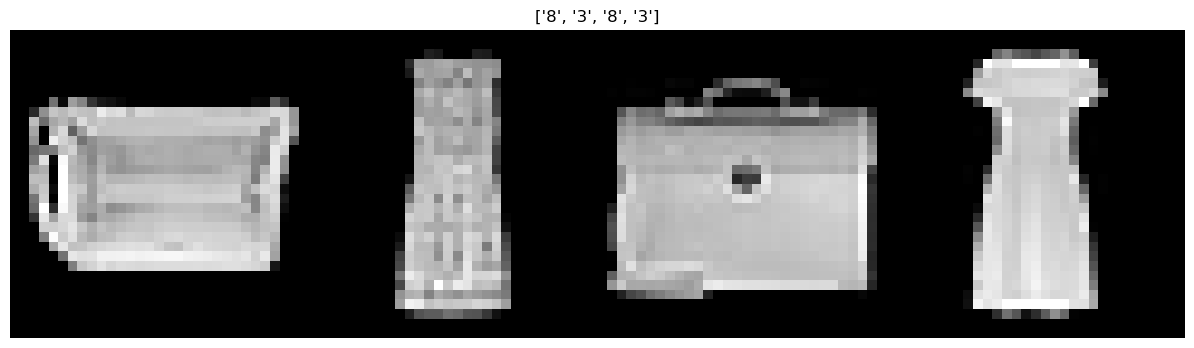

In [17]:
images, labels = show_batch_images(trainloader) # 생성된 이미지의 클래스도 위에 호출

In [19]:
class NormalNet(nn.Module):
    def __init__(self):
        super(NormalNet, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(784, 48), #28*28크기의 이미지의 입력은 784 -> 48
            nn.ReLU(), 
            nn.Linear(48, 24), # 노드 수 48->28
            nn.ReLU(), 
            nn.Linear(24, 10) # FashionMNIST는 클래스 10개임
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.classifier(x) # 앞에서 정의한 분류기 호출
        return x

In [21]:
class BNNet(nn.Module):
    def __init__(self):
        super(BNNet, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(784, 48), # (28 * 28) = 784 -> 48 nodes
            nn.BatchNorm1d(48), 
            nn.ReLU(), 
            nn.Linear(48, 24), # 48 -> 24 nodes
            nn.BatchNorm1d(24), 
            nn.ReLU(), 
            nn.Linear(24, 10) # FashionMNIST: 10 classes
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.classifier(x) # nn.Sequential에서 정의한 계층 호출
        return x

In [23]:
#배치 정규화 x 모델
model = NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [25]:
#배치 정규화있는 모델
model_bn = BNNet()
print(model_bn)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [27]:
# 데이터셋 메모리로 불러와서 옵티마이저 및 손실 함수도 지정하기
batch_size = 512
trainloader = torch.utils.data.DataLoader(trainset, 
                                          batch_size = batch_size, shuffle = True)
loss_fn = nn.CrossEntropyLoss()
opt = optim.SGD(model.parameters(), lr = 0.01)
opt_bn = optim.SGD(model_bn.parameters(), lr = 0.01)

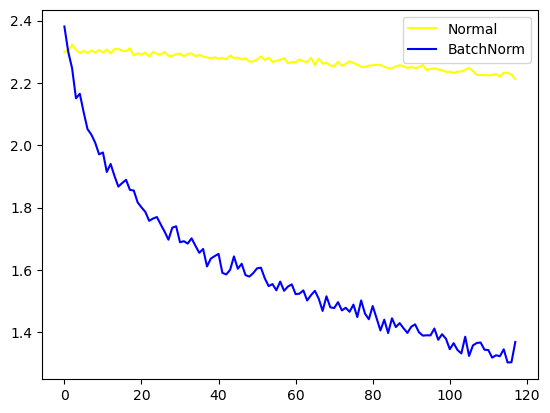

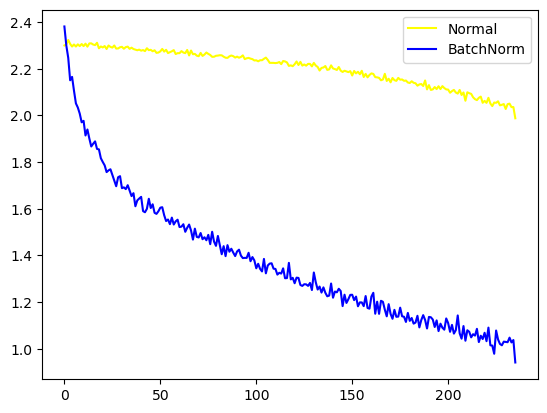

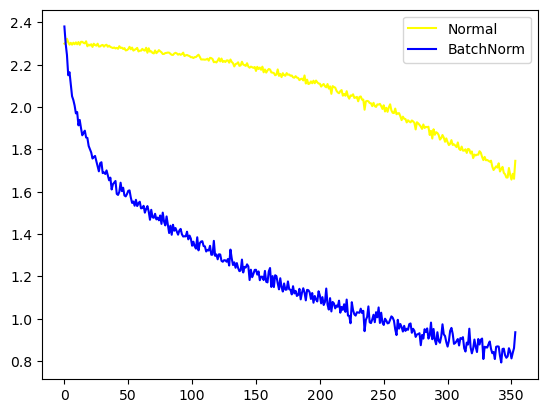

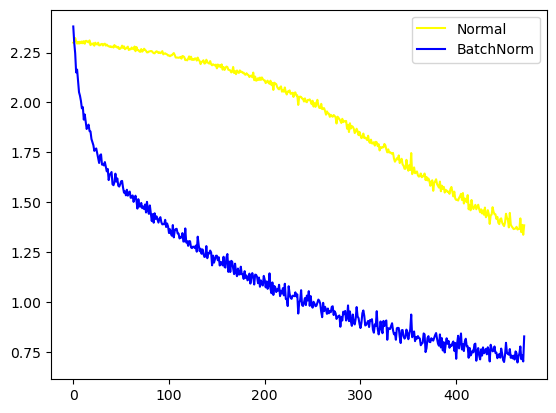

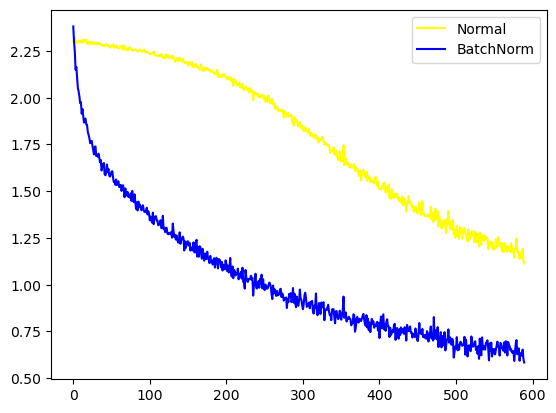

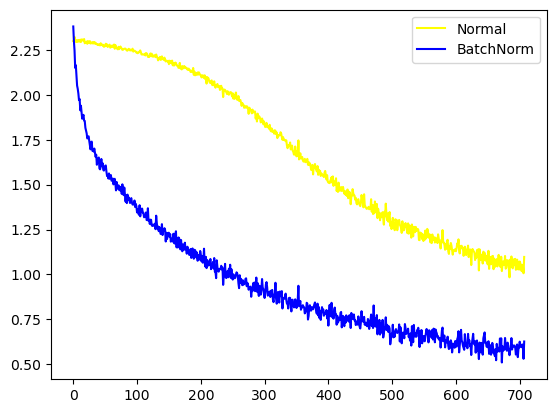

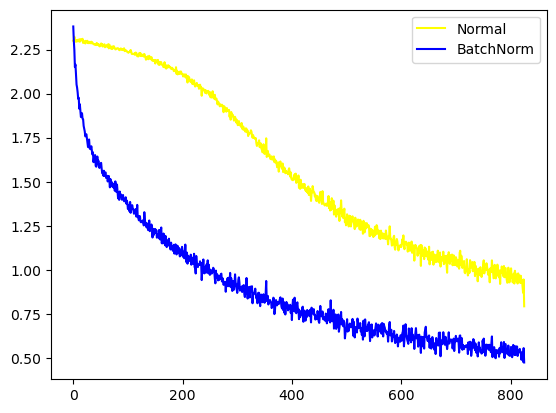

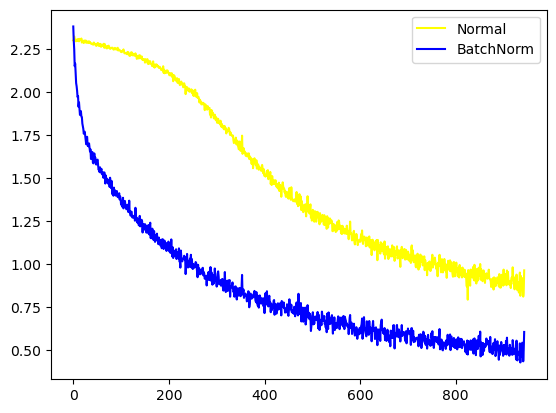

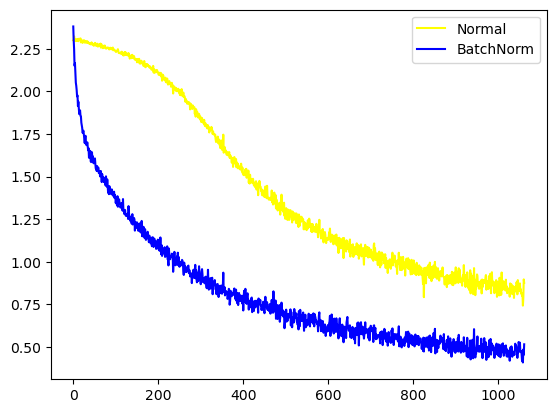

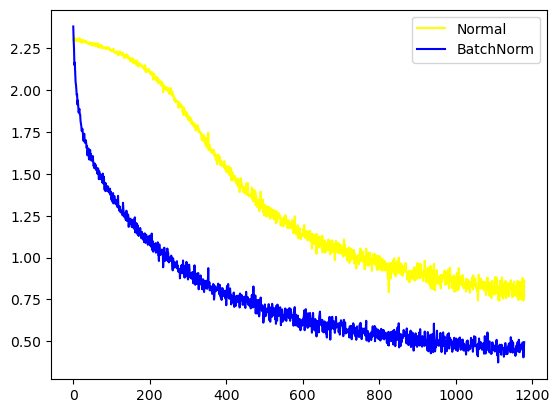

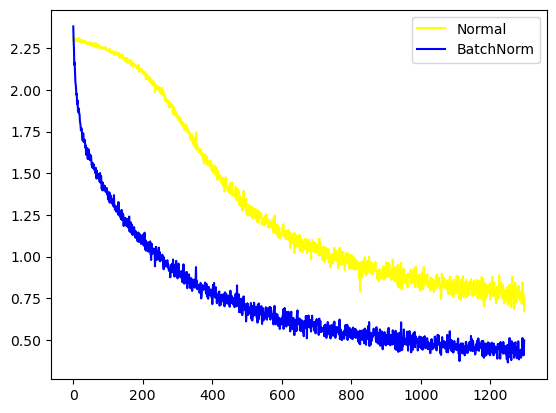

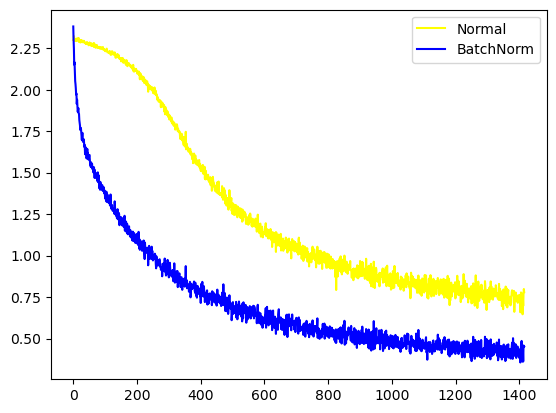

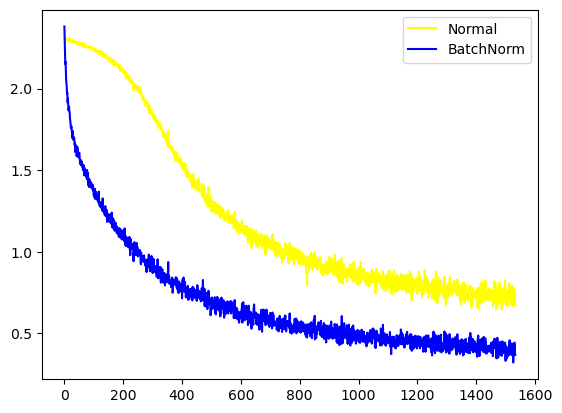

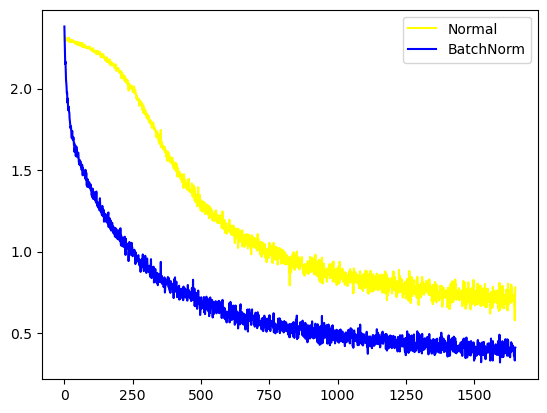

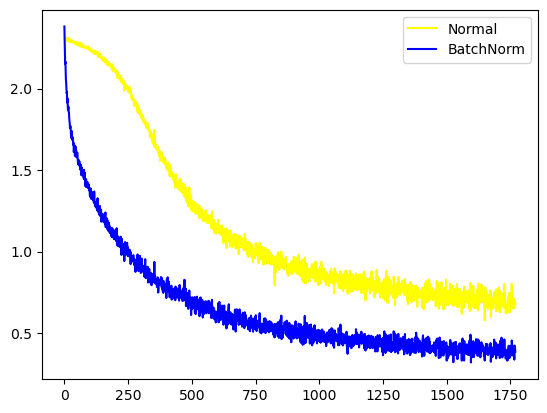

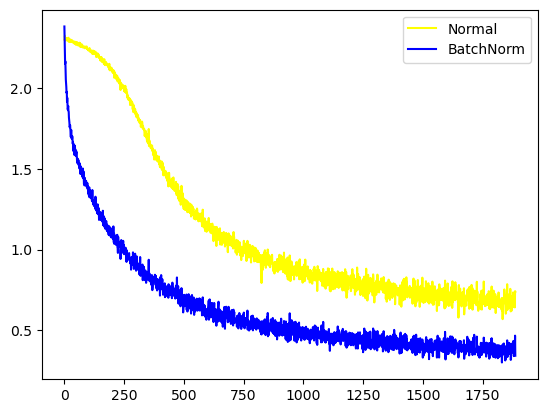

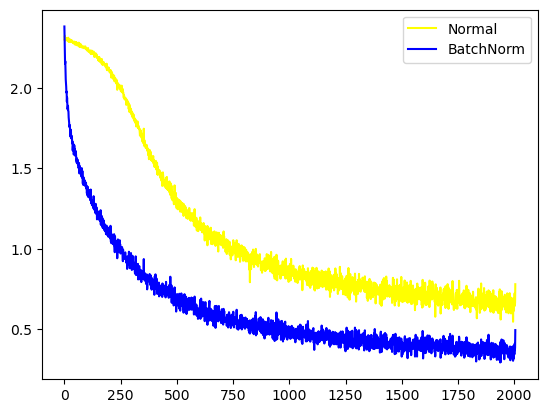

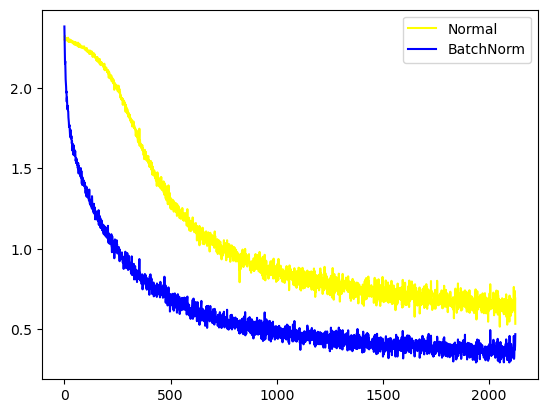

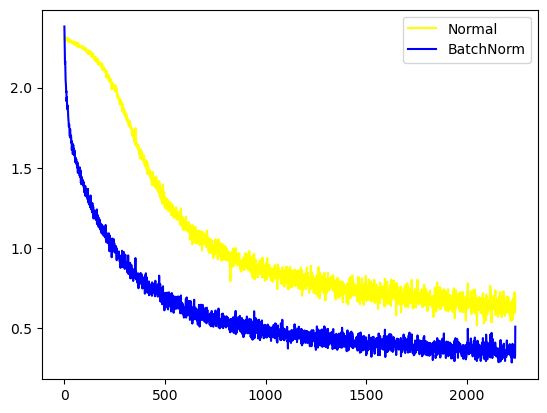

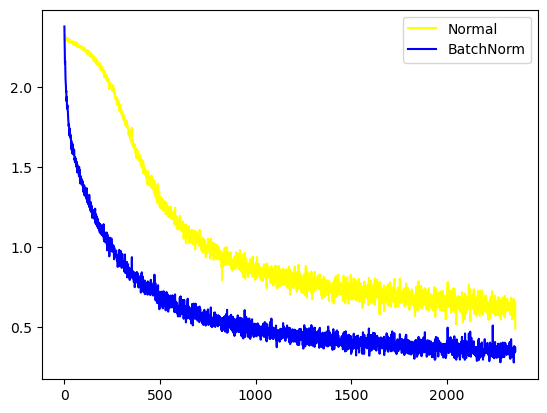

In [29]:
# 모델 학습하고 결과(오차 정보 보여주기)
loss_arr = []
loss_bn_arr = []
max_epochs = 20

for epoch in range(max_epochs):
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        opt.zero_grad() #배치 정규화 x 모델
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        opt.step()

        opt_bn.zero_grad() #배치 정규화있는 모델
        outputs_bn = model_bn(inputs)
        loss_bn = loss_fn(outputs_bn, labels)
        loss_bn.backward()
        opt_bn.step()

        loss_arr.append(loss.item())
        loss_bn_arr.append(loss_bn.item())

    plt.plot(loss_arr, 'yellow', label = 'Normal')
    plt.plot(loss_bn_arr, 'blue', label = 'BatchNorm')
    plt.legend()
    plt.show()

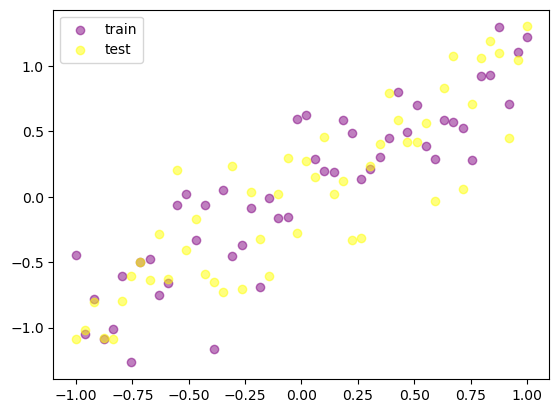

In [31]:
# 데이터셋의 분포를 출력하기 위한 전처리
N = 50
noise = 0.3

x_train = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_train = x_train + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

x_test = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_test = x_test + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

# 시각화
plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c= 'purple', 
            alpha=0.5, label = 'train')
plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c= 'yellow', 
            alpha=0.5, label = 'test')
plt.legend()
plt.show()

In [33]:
# 드롭아웃 모델 생성

In [35]:
N_h = 100
model = torch.nn.Sequential(
    torch.nn.Linear(1, N_h), 
    torch.nn.ReLU(), 
    torch.nn.Linear(N_h, N_h), 
    torch.nn.ReLU(), 
    torch.nn.Linear(N_h, 1)
) # Dropout x

model_dropout = torch.nn.Sequential(
    torch.nn.Linear(1, N_h), 
    torch.nn.Dropout(0.2), 
    torch.nn.ReLU(), 
    torch.nn.Linear(N_h, N_h), 
    torch.nn.Dropout(0.2), 
    torch.nn.ReLU(), 
    torch.nn.Linear(N_h, 1)
)

In [37]:
opt = torch.optim.Adam(model.parameters(), lr = 0.01)
opt_dropout = torch.optim.Adam(model_dropout.parameters(), lr = 0.01)
loss_fn = torch.nn.MSELoss()

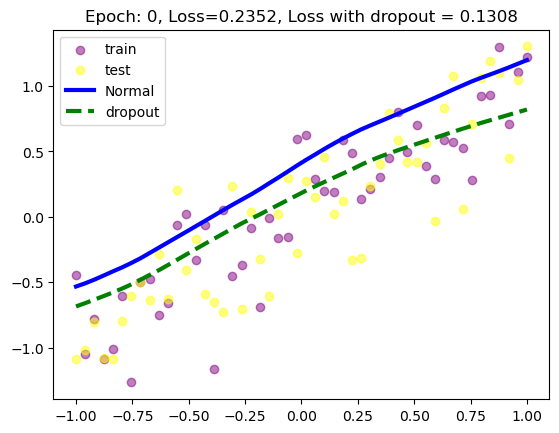

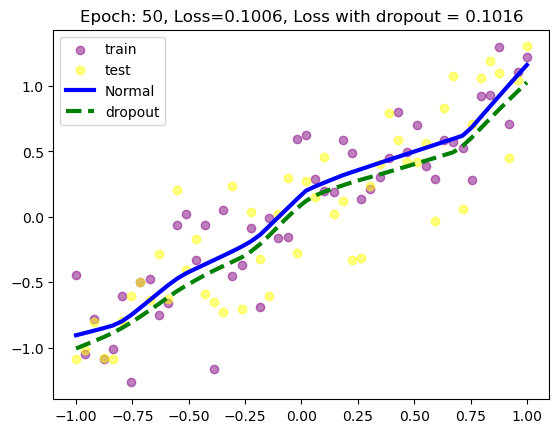

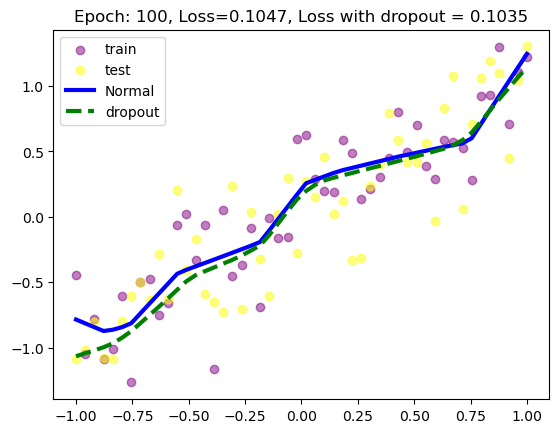

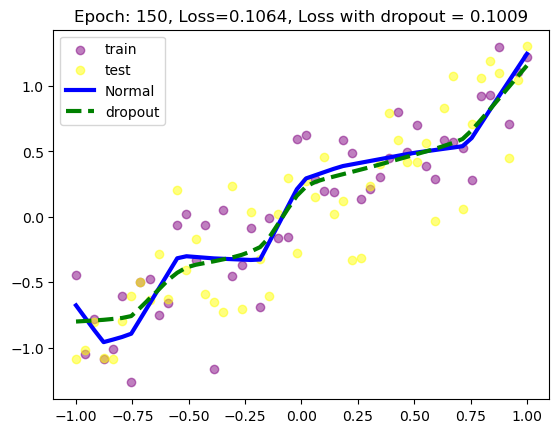

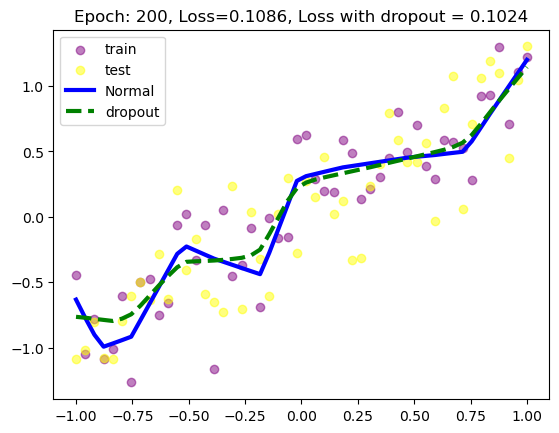

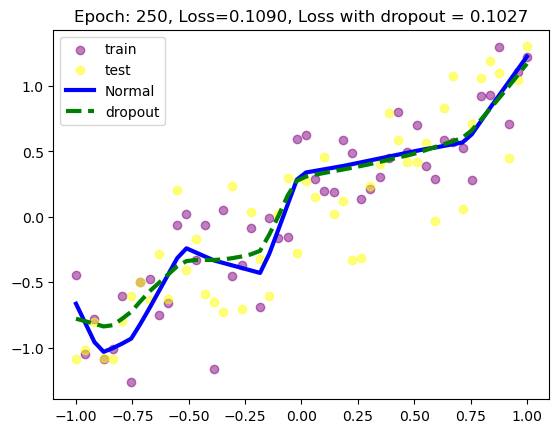

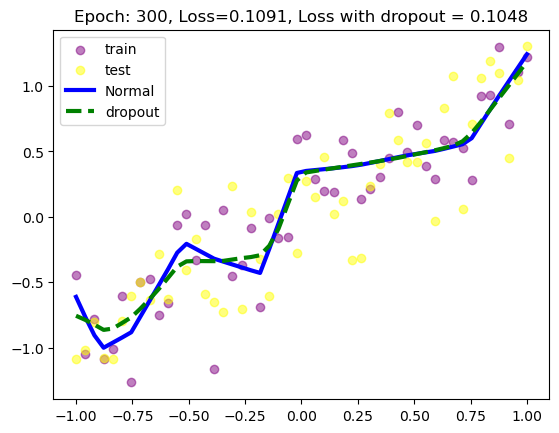

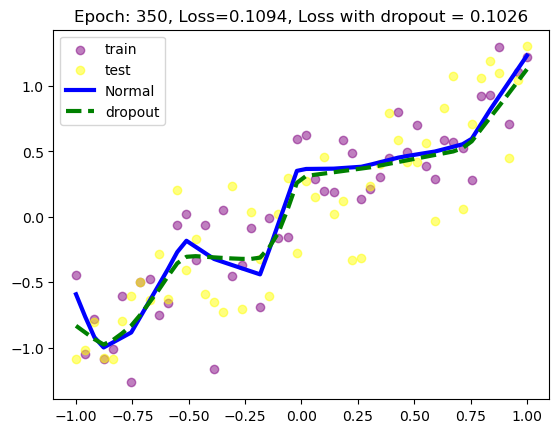

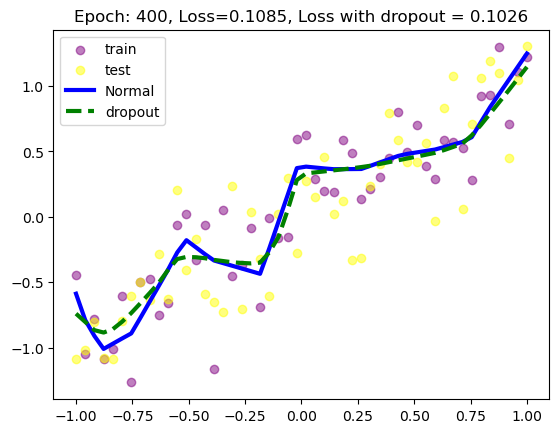

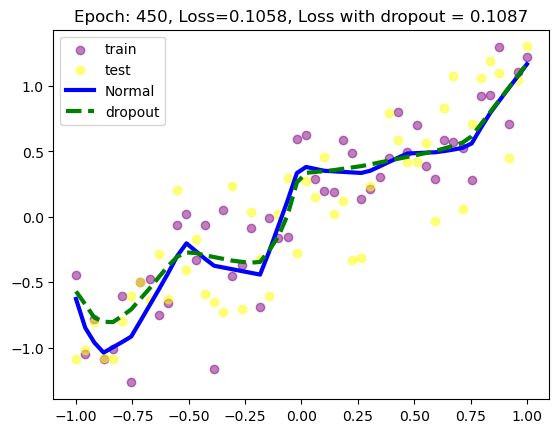

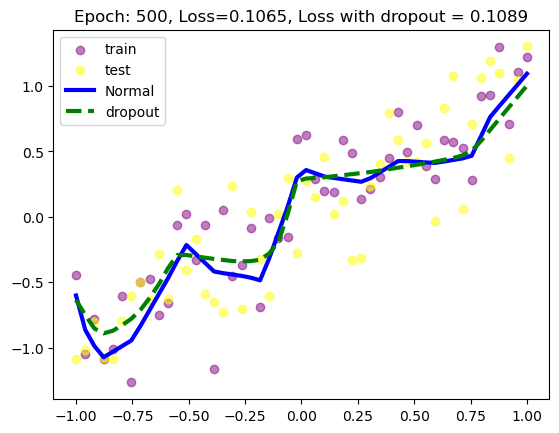

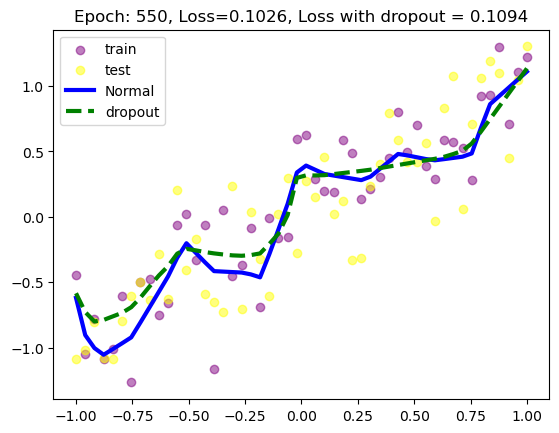

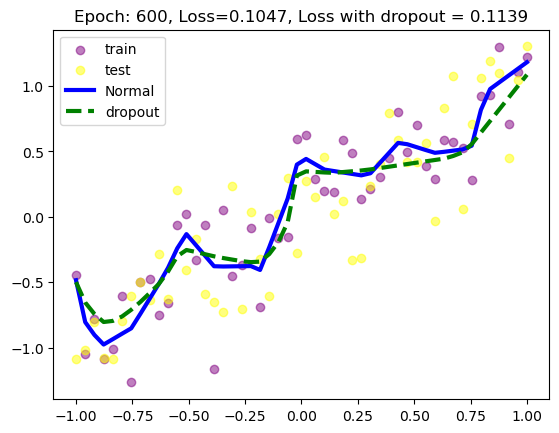

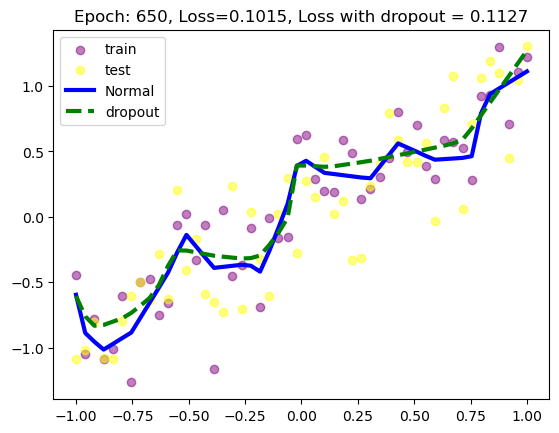

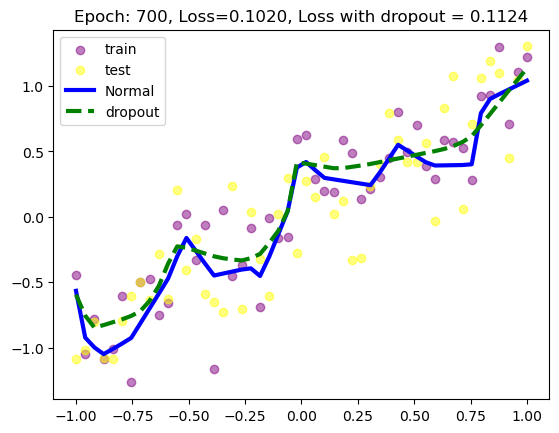

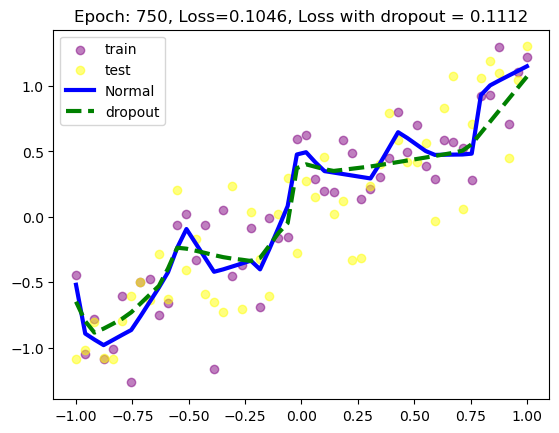

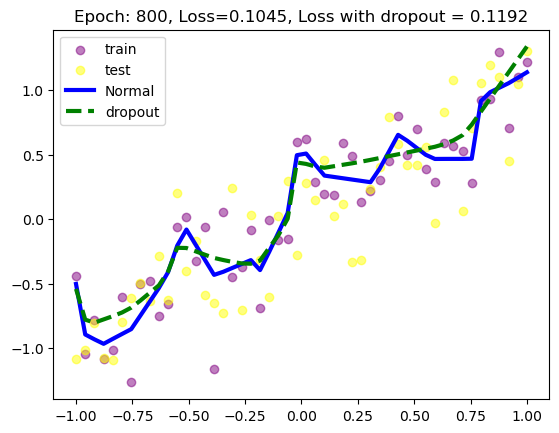

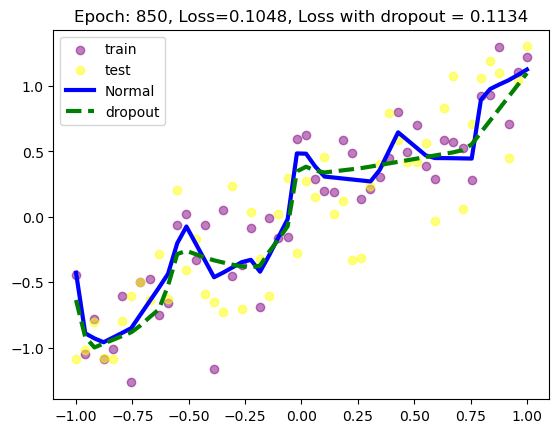

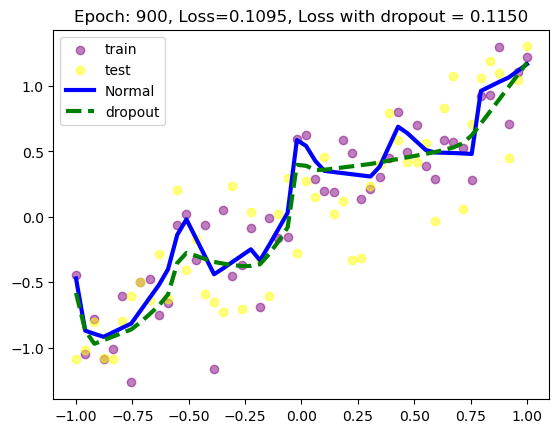

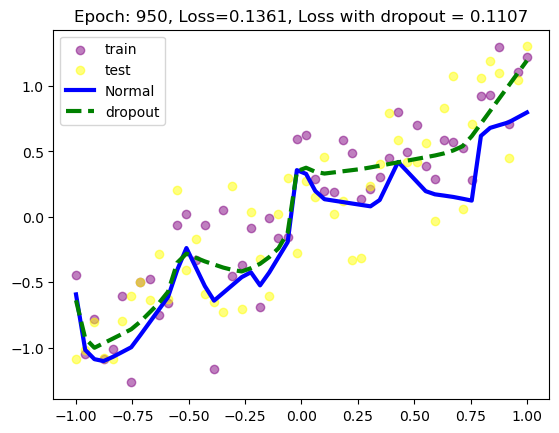

In [39]:
# 모델 학습 및 시각화
max_epochs = 1000
for epoch in range(max_epochs):
    pred = model(x_train)
    loss = loss_fn(pred, y_train)
    opt.zero_grad()
    loss.backward()
    opt.step()

    pred_dropout = model_dropout(x_train)
    loss_dropout = loss_fn(pred_dropout, y_train)
    opt_dropout.zero_grad()
    loss_dropout.backward()
    opt_dropout.step()

    if epoch % 50 == 0:
        model.eval()
        model_dropout.eval()

        test_pred = model(x_test)
        test_loss = loss_fn(test_pred, y_test)

        test_pred_dropout = model_dropout(x_test)
        test_loss_dropout = loss_fn(test_pred_dropout, y_test)

        plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c= 'purple', 
                    alpha = 0.5, label = 'train')
        plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c= 'yellow', 
                    alpha = 0.5, label = 'test')
        
        plt.plot(x_test.data.numpy(), test_pred.data.numpy(), 'b-', 
                 lw = 3, label = 'Normal')
        plt.plot(x_test.data.numpy(), test_pred_dropout.data.numpy(), 'g--', 
                 lw = 3, label = 'dropout')
        
        plt.title(f'Epoch: {epoch}, Loss={test_loss:.4f}, Loss with dropout = {test_loss_dropout:.4f}')

        plt.legend()
        model.train()
        model_dropout.train()
        plt.pause(0.05)


In [53]:
import torch
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import Food101

import torchvision
import torchvision.models as models # 사전 학습된 모델 이용할 때
from torchvision import transforms, datasets

import torch.nn as nn
import torch.optim as optim

import time
import argparse
from tqdm import tqdm
matplotlib.style.use('ggplot')
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

In [55]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.RandomHorizontalFlip(), 
    transforms.RandomVerticalFlip(), 
    transforms.ToTensor(), 
    transforms.Normalize(mean = [0.485, 0.456, 0.406], 
                         std = [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(), 
    transforms.Normalize(mean = [0.485, 0.456, 0.406], 
                         std = [0.229, 0.224, 0.225])
])

In [ ]:
train_dataset = datasets.ImageFolder(
    root = r'/Users/bluecloud/Documents/대학/Euron/data', 
    transform = train_transform
)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size = 16, shuffle = True
)
val_dataset = datasets.ImageFolder(
    root = r'/Users/bluecloud/Documents/대학/Euron/data', 
    transform = val_transform
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size = 16, shuffle = True
)

In [ ]:
def resnet50(pretrained=True):
    model = models.resnet50(progress=True, pretrained=pretrained)
    if requires_grad == False:
        for param in model.parameters():
            param.requires_grad = False
    elif requires_grad == True:
        for param in model.parameters():
            param.requires_grad = True
    model.fc = nn.Linear(2048, 2)
    return model

In [ ]:
class LRScheduler():
    def __init__(
        self, optimizer, patience=5, min_lr=1e-6, factor=0.5
    ):
        self.optimizer = optimizer
        self.patience = patience
        self.min_lr = min_lr
        self.factor = factor
        self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                self.optimizer,
                mode='min',
                patience=self.patience,
                factor=self.factor,
                min_lr=self.min_lr,
                verbose=True
            )
    def __call__(self, val_loss):
        self.lr_scheduler.step(val_loss)

In [ ]:

class EarlyStopping():
    def __init__(self, patience=5, verbose=False, delta=0, path='/Users/bluecloud/Documents/대학/Euron/checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [ ]:
parser = argparse.ArgumentParser()
parser.add_argument('--lr-scheduler', dest='lr_scheduler', action='store_true')
parser.add_argument('--early-stopping', dest='early_stopping', action='store_true')
parser.add_argument("-f", "--fff", help="a dummy argument to fool ipython", default="1")
args = vars(parser.parse_args())

In [ ]:
print(f"Computation device: {device}\n")
model = models.resnet50(pretrained=True).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.")

In [ ]:
lr = 0.001
epochs = 100
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

In [ ]:
loss_plot_name = 'loss'
acc_plot_name = 'accuracy'
model_name = 'model'

In [ ]:
if args['lr_scheduler']:
    print('INFO: Initializing learning rate scheduler')
    lr_scheduler = LRScheduler(optimizer)
    loss_plot_name = 'lrs_loss'
    acc_plot_name = 'lrs_accuracy'
    model_name = 'lrs_model'
if args['early_stopping']:
    print('INFO: Initializing early stopping')
    early_stopping = EarlyStopping()
    loss_plot_name = 'es_loss'
    acc_plot_name = 'es_accuracy'
    model_name = 'es_model'

In [ ]:
def training(model, train_dataloader, train_dataset, optimizer, criterion):
    print('Training')
    model.train()
    train_running_loss = 0.0
    train_running_correct = 0
    counter = 0
    total = 0
    prog_bar = tqdm(enumerate(train_dataloader), total=int(len(train_dataset)/train_dataloader.batch_size))
    for i, data in prog_bar:
        counter += 1
        data, target = data[0].to(device), data[1].to(device)
        total += target.size(0)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        train_running_loss += loss.item()
        _, preds = torch.max(outputs.data, 1)
        train_running_correct += (preds == target).sum().item()
        loss.backward()
        optimizer.step()

    train_loss = train_running_loss / counter
    train_accuracy = 100. * train_running_correct / total
    return train_loss, train_accuracy

In [ ]:
def validate(model, test_dataloader, val_dataset, criterion):
    print('Validating')
    model.eval()
    val_running_loss = 0.0
    val_running_correct = 0
    counter = 0
    total = 0
    prog_bar = tqdm(enumerate(test_dataloader), total=int(len(val_dataset)/test_dataloader.batch_size))
    with torch.no_grad():
        for i, data in prog_bar:
            counter += 1
            data, target = data[0].to(device), data[1].to(device)
            total += target.size(0)
            outputs = model(data)
            loss = criterion(outputs, target)

            val_running_loss += loss.item()
            _, preds = torch.max(outputs.data, 1)
            val_running_correct += (preds == target).sum().item()

        val_loss = val_running_loss / counter
        val_accuracy = 100. * val_running_correct / total
        return val_loss, val_accuracy

In [ ]:
train_loss, train_accuracy = [], []
val_loss, val_accuracy = [], []
start = time.time()
for epoch in range(epochs):
    print(f"Epoch {epoch+1} of {epochs}")
    train_epoch_loss, train_epoch_accuracy = training(
        model, train_dataloader, train_dataset, optimizer, criterion
    )
    val_epoch_loss, val_epoch_accuracy = validate(
        model, val_dataloader, val_dataset, criterion
    )
    train_loss.append(train_epoch_loss)
    train_accuracy.append(train_epoch_accuracy)
    val_loss.append(val_epoch_loss)
    val_accuracy.append(val_epoch_accuracy)
    if args['lr_scheduler']:
        lr_scheduler(val_epoch_loss)
    if args['early_stopping']:
        early_stopping(val_epoch_loss, model)
        if early_stopping.early_stop:
            break
    print(f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}")
    print(f'Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}')
end = time.time()
print(f"Training time: {(end-start)/60:.3f} minutes")
     

In [ ]:
plt.figure(figsize=(10, 7))
plt.plot(train_accuracy, color='green', label='train accuracy')
plt.plot(val_accuracy, color='blue', label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f"/content/chap08/img/{acc_plot_name}.png")
plt.show()

plt.figure(figsize=(10, 7))
plt.plot(train_loss, color='orange', label='train loss')
plt.plot(val_loss, color='red', label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f"/Users/bluecloud/Documents/대학/Euron/content/chap08/img/{loss_plot_name}.png")
plt.show()

print('Saving model...')
torch.save(model.state_dict(), f"/Users/bluecloud/Documents/대학/Euron/content/chap08/img/{model_name}.pth")
print('TRAINING COMPLETE')
     